# 🧬 Embryo Development Stage Classification
### MobileNet · InceptionV3 · VGG16 · VGG19 with Custom Ordinal Loss

**Dataset:** [Human Embryo Time-Lapse Video Dataset](https://zenodo.org/records/6390798)  
**Task:** Multi-class classification of 16 development phases from still frames  
**Models:** MobileNetV2, InceptionV3, VGG16, VGG19 (transfer learning + fine-tuning)  
**Custom Loss:** Ordinal-aware Weighted Cross-Entropy + Earth Mover's Distance regularization

---
## 📋 16 Development Phases (in order)
| Phase | Event | Description |
|-------|-------|-------------|
| pPB2  | tPB2  | Second polar body detached |
| pPNa  | tPNa  | Pro-nuclei appearance |
| pPNf  | tPNf  | Pro-nuclei disappearance |
| p2    | t2    | 2-cell stage |
| p3    | t3    | 3-cell stage |
| p4    | t4    | 4-cell stage |
| p5    | t5    | 5-cell stage |
| p6    | t6    | 6-cell stage |
| p7    | t7    | 7-cell stage |
| p8    | t8    | 8-cell stage |
| p9+   | t9+   | 9+ cells stage |
| pM    | tM    | End of compaction |
| pSB   | tSB   | Start of blastulation |
| pB    | tB    | Full blastocyst |
| pEB   | tEB   | Expanded blastocyst |
| pHB   | tHB   | Hatched blastocyst |

> **Key insight:** These phases are *strictly ordered* — misclassifying p4 as p8 is worse than misclassifying it as p3. Our custom loss exploits this ordinal structure.

---

## Cell 1 — Install & Import Dependencies

In [1]:
# ── Install any missing packages ──
!pip install -q kaggle

import os, sys, json, random, shutil, math, time
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── TensorFlow / Keras ──
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.applications import (
    MobileNetV2, InceptionV3, VGG16, VGG19
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Sklearn
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, mean_absolute_error
)
from sklearn.model_selection import train_test_split

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU check ──
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow {tf.__version__}')
print(f'GPUs available: {len(gpus)}')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
        print(f'  {g}')

print('✅ Imports done')

2026-04-06 05:50:03.989538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775454604.164440      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775454604.213238      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775454604.626842      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775454604.626885      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775454604.626890      55 computation_placer.cc:177] computation placer alr

TensorFlow 2.19.0
GPUs available: 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
✅ Imports done


## Cell 2 — Configuration

In [2]:
# ═══════════════════════════════════════════════════════════
#  GLOBAL CONFIGURATION — FINAL (SAFE + OPTIMIZED)
# ═══════════════════════════════════════════════════════════
from pathlib import Path

DATA_ROOT  = Path('/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset')

ANNOT_DIR  = DATA_ROOT / 'embryo_dataset_annotations' / 'embryo_dataset_annotations'
FRAMES_DIR = DATA_ROOT / 'embryo_dataset' / 'embryo_dataset'

OUTPUT_DIR = Path('/kaggle/working/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("\n📁 Path check:")
print("ANNOT_DIR exists:", ANNOT_DIR.exists())
print("FRAMES_DIR exists:", FRAMES_DIR.exists())

# ── 16 Phase labels in strict developmental order ──
PHASES = [
    'pPB2','pPNa','pPNf','p2','p3','p4','p5',
    'p6','p7','p8','p9+','pM','pSB','pB','pEB','pHB'
]

N_CLASSES   = len(PHASES)
PHASE2IDX   = {p: i for i, p in enumerate(PHASES)}
IDX2PHASE   = {i: p for p, i in PHASE2IDX.items()}

# ── Annotation column mapping ──
TPHASES = [
    'tPB2','tPNa','tPNf','t2','t3','t4','t5',
    't6','t7','t8','t9+','tM','tSB','tB','tEB','tHB'
]

TPHASE2PPHASE = dict(zip(TPHASES, PHASES))

# ── Image & training hyperparameters ──
IMG_SIZE       = 224
INCEPTION_SIZE = 299
BATCH_SIZE     = 32

EPOCHS_FROZEN   = 10
EPOCHS_FINETUNE = 10

LR_FROZEN   = 1e-3
LR_FINETUNE = 1e-5

VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15

# ── Custom loss ──
ALPHA_EMD = 0.3

print("\n⚙️ CONFIG SUMMARY")
print(f'Phases: {PHASES}')
print(f'N_CLASSES: {N_CLASSES}')
print(f'IMG_SIZE: {IMG_SIZE}x{IMG_SIZE}')
print(f'BATCH_SIZE: {BATCH_SIZE}')
print('✅ Config ready')


📁 Path check:
ANNOT_DIR exists: True
FRAMES_DIR exists: True

⚙️ CONFIG SUMMARY
Phases: ['pPB2', 'pPNa', 'pPNf', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9+', 'pM', 'pSB', 'pB', 'pEB', 'pHB']
N_CLASSES: 16
IMG_SIZE: 224x224
BATCH_SIZE: 32
✅ Config ready


In [3]:
from pathlib import Path

base = Path('/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset')
for item in sorted(base.iterdir()):
    print(f"  {'[DIR]' if item.is_dir() else '[FILE]'} {item.name}")

  [DIR] embryo_dataset
  [DIR] embryo_dataset_annotations


## Cell 3 — Download Dataset from Zenodo

**Instructions:**
1. Go to [https://zenodo.org/records/6390798](https://zenodo.org/records/6390798)
2. Download `embryo_dataset.tar.gz` and `embryo_dataset_annotations.tar.gz`
3. Upload to a Kaggle Dataset (or use the Kaggle API shown below)
4. Alternatively, run the cell below directly on Kaggle (internet must be ON)

## Cell 4 — Parse Annotations → Master DataFrame

In [4]:
import re
from pathlib import Path
from tqdm.notebook import tqdm
import pandas as pd

# ── Parse one annotation CSV ──
def parse_annotation_csv(csv_path: Path) -> pd.DataFrame:
    embryo_id = csv_path.stem.replace('_phases', '')
    
    try:
        df_annot = pd.read_csv(
            csv_path, sep=',', header=None,
            names=['t_phase', 'start_frame', 'end_frame'],
            engine='python'
        )
    except Exception as e:
        print(f'  ⚠️  Could not parse {csv_path.name}: {e}')
        return pd.DataFrame()

    if df_annot.shape[1] != 3:
        print(f'  ⚠️  Unexpected columns in {csv_path.name}: {df_annot.shape}')
        return pd.DataFrame()

    records = []
    for _, row in df_annot.iterrows():
        try:
            t_phase = str(row['t_phase']).strip()
        except Exception:
            continue

        p_phase = TPHASE2PPHASE.get(t_phase)
        if p_phase is None:
            continue

        # Skip phases not in the current PHASE2IDX (e.g. pHB if already dropped)
        if p_phase not in PHASE2IDX:
            continue

        phase_idx = PHASE2IDX[p_phase]
        try:
            start = int(row['start_frame'])
            end   = int(row['end_frame'])
        except (ValueError, TypeError):
            continue

        for fr in range(start, end + 1):
            records.append({
                'embryo_id':   embryo_id,
                'frame_idx':   fr,
                'phase_label': p_phase,
                'phase_idx':   phase_idx
            })

    return pd.DataFrame(records)


# ── Build per-embryo frame index ──
def build_embryo_index(frames_dir: Path) -> dict:
    run_re = re.compile(r'_RUN(\d+)\.(jpeg|jpg)$', re.IGNORECASE)
    embryo_dirs = [d for d in frames_dir.iterdir() if d.is_dir()]
    print(f'Indexing {len(embryo_dirs)} embryo folders...')

    index = {}
    for embryo_dir in tqdm(embryo_dirs):
        eid = embryo_dir.name
        index[eid] = {}
        for fpath in embryo_dir.iterdir():
            m = run_re.search(fpath.name)
            if m:
                frame_num = int(m.group(1))
                index[eid][frame_num] = str(fpath)

    return index


# ── Build master DataFrame ──
def build_master_df(annot_dir: Path, frames_dir: Path) -> pd.DataFrame:
    csv_files = sorted(annot_dir.glob('*.csv'))
    print(f'Found {len(csv_files)} annotation CSVs')

    if len(csv_files) == 0:
        raise FileNotFoundError(f'No CSVs found in {annot_dir}. Check extraction.')

    sample_csv = csv_files[0]
    print(f'\nSample CSV ({sample_csv.name}) first 5 lines:')
    with open(sample_csv) as f:
        for i, line in enumerate(f):
            if i >= 5:
                break
            print(f'  {repr(line.rstrip())}')
    print()

    all_dfs = []
    n_empty = 0
    for csv_path in tqdm(csv_files, desc='Parsing CSVs'):
        df = parse_annotation_csv(csv_path)
        if df.empty:
            n_empty += 1
        else:
            all_dfs.append(df)

    if n_empty > 0:
        print(f'⚠️  {n_empty} CSVs yielded no records')
    if len(all_dfs) == 0:
        raise ValueError('All CSVs parsed empty. Check separator or phase name mapping.')

    master = pd.concat(all_dfs, ignore_index=True)
    print(f'Total annotation rows (before image check): {len(master):,}')

    embryo_folders = [d for d in frames_dir.iterdir() if d.is_dir()]
    if embryo_folders:
        sample_folder = sorted(embryo_folders)[0]
        sample_files  = sorted(sample_folder.iterdir())[:5]
        print(f'\nSample image folder ({sample_folder.name}):')
        for f in sample_files:
            print(f'  {f.name}')
        print()

    embryo_index = build_embryo_index(frames_dir)

    print('Attaching image paths...')
    img_paths = []
    for _, row in tqdm(master.iterrows(), total=len(master), desc='Mapping paths'):
        eid = row['embryo_id']
        fr  = int(row['frame_idx'])
        p   = embryo_index.get(eid, {}).get(fr, None)
        img_paths.append(p)

    master['img_path'] = img_paths

    missing = master['img_path'].isna().sum()
    total   = len(master)
    print(f'\nImage path results:')
    print(f'  Found:   {total - missing:,}')
    print(f'  Missing: {missing:,}  ({100 * missing / total:.1f}%)')

    if missing == total:
        raise FileNotFoundError('No images matched. Check the sample folder output above.')
    if missing > 0:
        print('  Dropping rows with missing images...')

    master = master.dropna(subset=['img_path']).reset_index(drop=True)

    print(f'\nFinal master DataFrame: {len(master):,} rows')
    print(f'Unique embryos:         {master["embryo_id"].nunique()}')

    return master


# ── Reset globals to full 16 classes before parsing ──
PHASES = [
    'pPB2','pPNa','pPNf','p2','p3','p4','p5',
    'p6','p7','p8','p9+','pM','pSB','pB','pEB','pHB'
]
TPHASES = [
    'tPB2','tPNa','tPNf','t2','t3','t4','t5',
    't6','t7','t8','t9+','tM','tSB','tB','tEB','tHB'
]
TPHASE2PPHASE = dict(zip(TPHASES, PHASES))
PHASE2IDX     = {p: i for i, p in enumerate(PHASES)}
IDX2PHASE     = {i: p for p, i in PHASE2IDX.items()}
N_CLASSES     = len(PHASES)

# ── Run ──
df_master = build_master_df(ANNOT_DIR, FRAMES_DIR)

# ── Health check: drop rare classes and update globals ──
print('\n=== DATASET HEALTH CHECK ===\n')
print(f'Embryos with images : {df_master["embryo_id"].nunique()} / 704')
print(f'Total labeled frames: {len(df_master):,}\n')

counts = df_master['phase_label'].value_counts().reindex(PHASES)
rare   = counts[counts < 50]
if len(rare) > 0:
    print('⚠️  Rare classes (< 50 samples) — will be DROPPED:')
    print(rare.to_string())
    print()

RARE_PHASES = list(rare.index)
df_master   = df_master[~df_master['phase_label'].isin(RARE_PHASES)].reset_index(drop=True)
PHASES      = [p for p in PHASES if p not in RARE_PHASES]
N_CLASSES   = len(PHASES)
PHASE2IDX   = {p: i for i, p in enumerate(PHASES)}
IDX2PHASE   = {i: p for p, i in PHASE2IDX.items()}
df_master['phase_idx'] = df_master['phase_label'].map(PHASE2IDX)

print(f'Active phases ({N_CLASSES}): {PHASES}')
print(f'Dropped phases:        {RARE_PHASES}')
print(f'\nFinal phase distribution:')
print(df_master['phase_label'].value_counts().reindex(PHASES).to_string())
print(f'\nFinal usable frames: {len(df_master):,}')
print(f'Unique embryos:      {df_master["embryo_id"].nunique()}')

assert df_master['phase_idx'].isna().sum() == 0
assert df_master['phase_idx'].max() == N_CLASSES - 1

print('\n✅ Cell 4 complete')

Found 704 annotation CSVs

Sample CSV (AA83-7_phases.csv) first 5 lines:
  'tPB2,5,24'
  'tPNa,25,88'
  'tPNf,89,97'
  't2,98,171'
  't3,172,177'



Parsing CSVs:   0%|          | 0/704 [00:00<?, ?it/s]

Total annotation rows (before image check): 302,134

Sample image folder (AA83-7):
  D2013.01.28_S0717_I132_WELL7_RUN1.jpeg
  D2013.01.28_S0717_I132_WELL7_RUN10.jpeg
  D2013.01.28_S0717_I132_WELL7_RUN100.jpeg
  D2013.01.28_S0717_I132_WELL7_RUN101.jpeg
  D2013.01.28_S0717_I132_WELL7_RUN102.jpeg

Indexing 704 embryo folders...


  0%|          | 0/704 [00:00<?, ?it/s]

Attaching image paths...


Mapping paths:   0%|          | 0/302134 [00:00<?, ?it/s]


Image path results:
  Found:   297,428
  Missing: 4,706  (1.6%)
  Dropping rows with missing images...

Final master DataFrame: 297,428 rows
Unique embryos:         704

=== DATASET HEALTH CHECK ===

Embryos with images : 704 / 704
Total labeled frames: 297,428

Active phases (16): ['pPB2', 'pPNa', 'pPNf', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9+', 'pM', 'pSB', 'pB', 'pEB', 'pHB']
Dropped phases:        []

Final phase distribution:
phase_label
pPB2     8895
pPNa    43244
pPNf     6793
p2      29189
p3       5127
p4      29177
p5       8045
p6       8366
p7      10531
p8      32602
p9+     51112
pM      17084
pSB     17244
pB      10387
pEB     19535
pHB        97

Final usable frames: 297,428
Unique embryos:      704

✅ Cell 4 complete


## Cell 5 — Exploratory Data Analysis

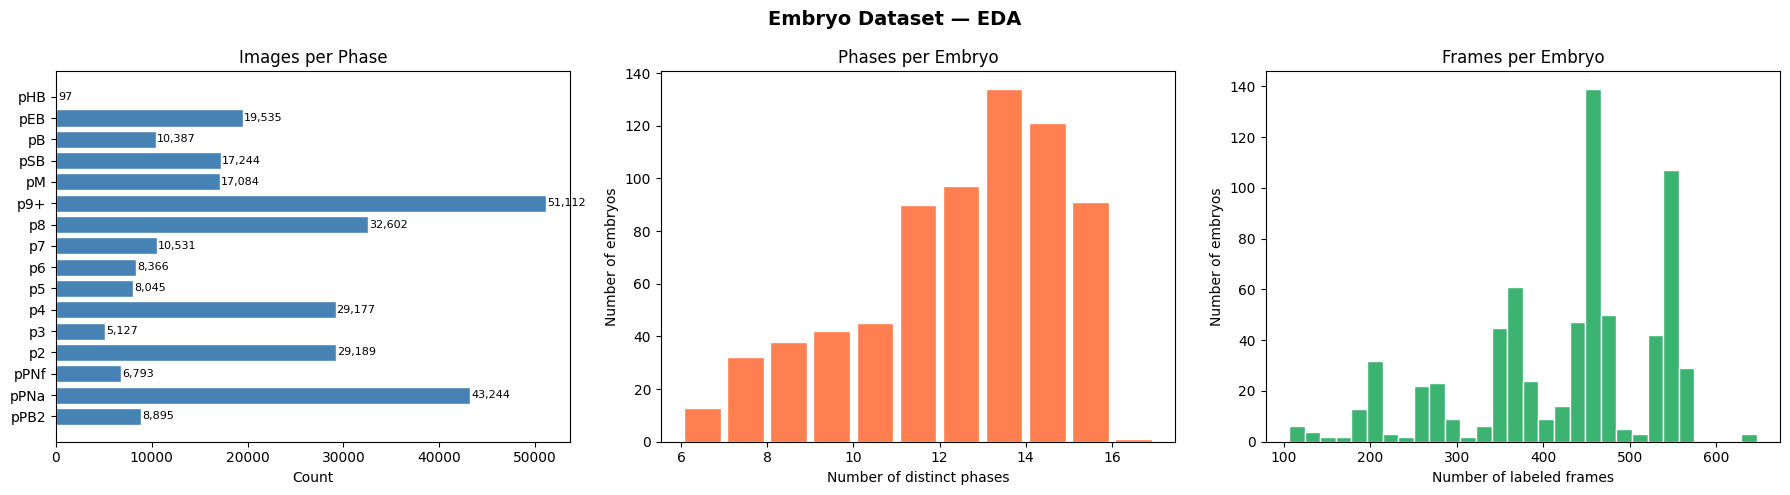


Class imbalance ratio (max/min): 526.9x
→ Custom loss will use inverse-frequency class weights to handle this.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Embryo Dataset — EDA', fontsize=14, fontweight='bold')

# (a) Images per phase
counts = df_master['phase_label'].value_counts().reindex(PHASES)
axes[0].barh(PHASES, counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Images per Phase')
axes[0].set_xlabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=8)

# (b) Phase distribution by embryo count
phases_per_embryo = df_master.groupby('embryo_id')['phase_label'].nunique()
axes[1].hist(phases_per_embryo.values, bins=range(6, 18), color='coral',
             edgecolor='white', rwidth=0.85)
axes[1].set_title('Phases per Embryo')
axes[1].set_xlabel('Number of distinct phases')
axes[1].set_ylabel('Number of embryos')

# (c) Frames per embryo
frames_per_embryo = df_master.groupby('embryo_id').size()
axes[2].hist(frames_per_embryo.values, bins=30, color='mediumseagreen',
             edgecolor='white')
axes[2].set_title('Frames per Embryo')
axes[2].set_xlabel('Number of labeled frames')
axes[2].set_ylabel('Number of embryos')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda.png', dpi=120, bbox_inches='tight')
plt.show()

# Class imbalance ratio
imbalance = counts.max() / counts.min()
print(f'\nClass imbalance ratio (max/min): {imbalance:.1f}x')
print('→ Custom loss will use inverse-frequency class weights to handle this.')

## Cell 6 — Sample Frame Visualization

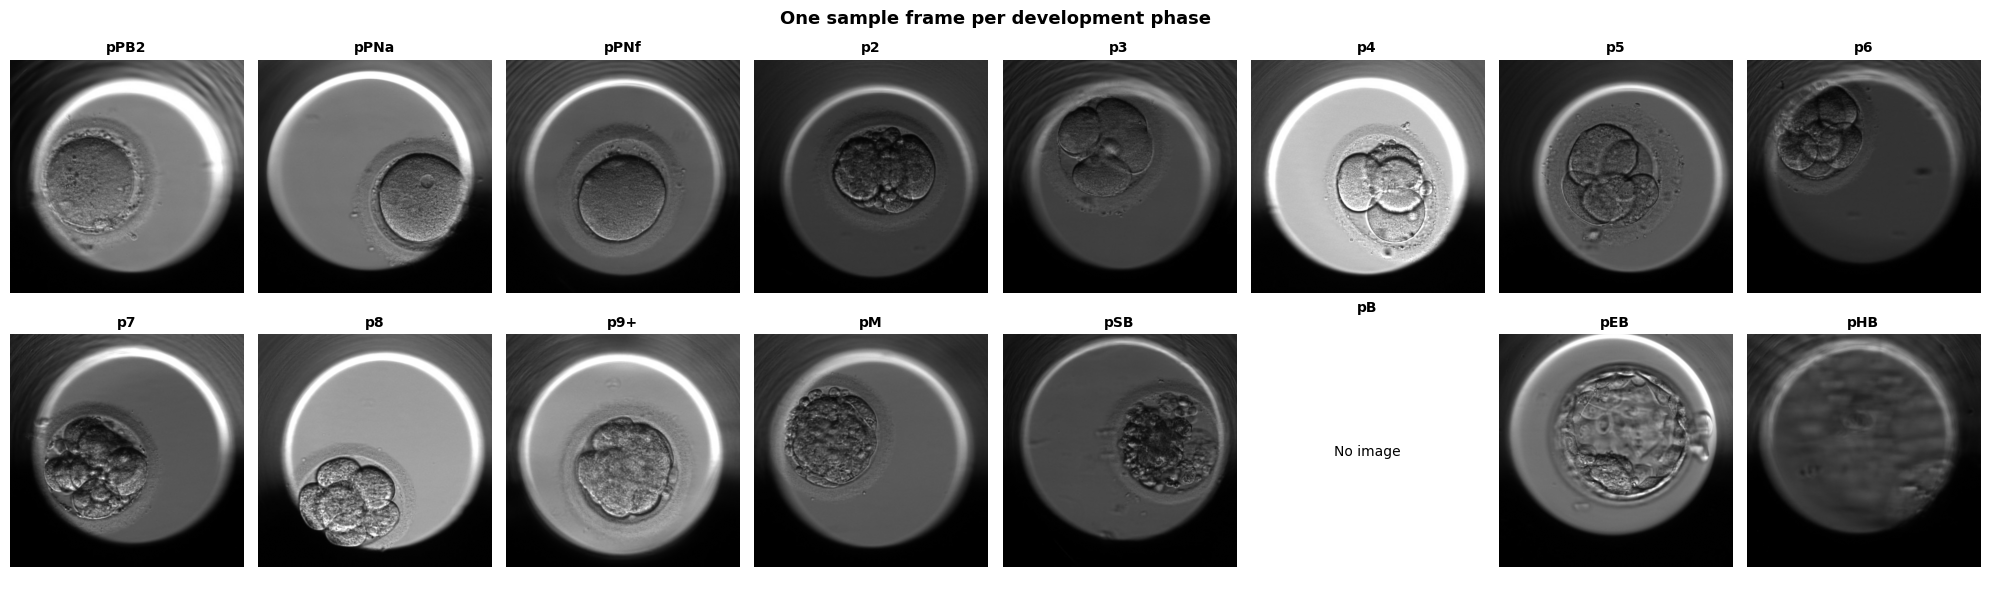

✅ Sample frames visualized


In [6]:
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('One sample frame per development phase', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, phase in enumerate(PHASES):
    subset = df_master[df_master['phase_label'] == phase]
    if len(subset) == 0:
        axes[i].axis('off')
        continue
    row = subset.sample(1, random_state=SEED).iloc[0]
    try:
        img = Image.open(row['img_path']).convert('L')
        axes[i].imshow(img, cmap='gray', vmin=0, vmax=255)
    except Exception:
        axes[i].text(0.5, 0.5, 'No image', ha='center', va='center')
    axes[i].set_title(phase, fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_frames.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Sample frames visualized')

## Cell 7 — Train / Validation / Test Split

> **Important:** We split by **embryo_id** (not by frame), to prevent data leakage —  
> frames from the same embryo are highly correlated and must not span train/test.

In [7]:
# ── Split by embryo ID to prevent leakage ──
embryo_ids = df_master['embryo_id'].unique()
np.random.shuffle(embryo_ids)

n_total = len(embryo_ids)
n_test  = int(n_total * TEST_SPLIT)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_test - n_val

train_ids = embryo_ids[:n_train]
val_ids   = embryo_ids[n_train:n_train + n_val]
test_ids  = embryo_ids[n_train + n_val:]

df_train = df_master[df_master['embryo_id'].isin(train_ids)].reset_index(drop=True)
df_val   = df_master[df_master['embryo_id'].isin(val_ids)].reset_index(drop=True)
df_test  = df_master[df_master['embryo_id'].isin(test_ids)].reset_index(drop=True)

print(f'Embryo split:  {n_train} train | {n_val} val | {n_test} test')
print(f'Frame split:   {len(df_train):,} train | {len(df_val):,} val | {len(df_test):,} test')

# ── Compute class weights for the custom loss ──
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(N_CLASSES),
    y=df_train['phase_idx'].values
)
CLASS_WEIGHTS = dict(enumerate(class_weights_array))
CLASS_WEIGHTS_TENSOR = tf.constant(class_weights_array, dtype=tf.float32)

print(f'\nClass weights (balanced):')
for i, p in enumerate(PHASES):
    print(f'  {p:5s}: {class_weights_array[i]:.3f}')

print('\n✅ Splits created')

Embryo split:  494 train | 105 val | 105 test
Frame split:   211,031 train | 42,927 val | 43,470 test

Class weights (balanced):
  pPB2 : 2.053
  pPNa : 0.428
  pPNf : 2.827
  p2   : 0.633
  p3   : 3.724
  p4   : 0.640
  p5   : 2.320
  p6   : 2.202
  p7   : 1.803
  p8   : 0.564
  p9+  : 0.373
  pM   : 1.078
  pSB  : 1.034
  pB   : 1.895
  pEB  : 0.914
  pHB  : 185.767

✅ Splits created


I0000 00:00:1775454681.706367      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## Cell 8 — Custom Loss Functions

### Design Rationale

Standard cross-entropy treats all misclassifications equally.  
For ordered embryo stages this is wrong: predicting **p4** when truth is **p5** is a minor error;  
predicting **pHB** when truth is **p2** is a catastrophic error.

Our custom loss has three components:

1. **Weighted Cross-Entropy** — handles class imbalance via inverse-frequency weights  
2. **Ordinal Penalty** — adds `|predicted_rank - true_rank|` proportional penalty  
3. **Earth Mover's Distance (EMD)** — measures "effort" to redistribute predicted  
   probability mass to the true label's position along the ordinal axis

$$\mathcal{L} = \mathcal{L}_{WCE} + \alpha \cdot \mathcal{L}_{EMD}$$

All three properties are satisfied:
- ✅ **Non-negative** — both WCE and EMD are ≥ 0
- ✅ **Zero iff perfect** — both terms are 0 only when predicted = true label
- ✅ **Ordinal-aware** — larger rank distance → larger penalty
- ✅ **Differentiable** — smooth w.r.t. softmax outputs
- ✅ **Bounded gradient** — no exploding gradients

In [8]:
class OrdinalEMDLoss(tf.keras.losses.Loss):
    """
    Custom loss for ordered class classification.

    L = WCE(y_true, y_pred) + alpha * EMD(y_true, y_pred)

    Properties:
    1. L >= 0
    2. L = 0 iff y_pred = y_true
    3. Ordinal penalty increases with |rank(pred) - rank(true)|
    4. Differentiable everywhere in the probability simplex interior
    5. Bounded: EMD in [0, 1] (normalized); WCE in [0, inf)
    """

    def __init__(self, class_weights, alpha=0.3,
                 n_classes=15, name='ordinal_emd_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.alpha = alpha
        self.n_classes = n_classes
        self.class_weights = tf.constant(class_weights, dtype=tf.float32)

    def _weighted_cross_entropy(self, y_true_oh, y_pred_prob):
        eps = 1e-7
        log_pred = tf.math.log(tf.clip_by_value(y_pred_prob, eps, 1.0 - eps))
        w = tf.reshape(self.class_weights, (1, self.n_classes))
        w_norm = w / tf.reduce_sum(self.class_weights)
        return -tf.reduce_mean(tf.reduce_sum(w_norm * y_true_oh * log_pred, axis=1))

    def _earth_movers_distance(self, y_true_oh, y_pred_prob):
        cdf_true = tf.cumsum(y_true_oh, axis=1)
        cdf_pred = tf.cumsum(y_pred_prob, axis=1)
        emd_per_sample = tf.reduce_sum(tf.abs(cdf_pred - cdf_true), axis=1)
        return tf.reduce_mean(emd_per_sample / float(self.n_classes - 1))

    def call(self, y_true, y_pred):
        y_pred_prob = tf.nn.softmax(y_pred, axis=-1)
        y_true_int = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true_int, self.n_classes)
        wce = self._weighted_cross_entropy(y_true_oh, y_pred_prob)
        emd = self._earth_movers_distance(y_true_oh, y_pred_prob)
        return wce + self.alpha * emd

    def get_config(self):
        config = super().get_config()
        config.update({'alpha': self.alpha, 'n_classes': self.n_classes})
        return config


# ── Unit tests ──
print('Unit-testing OrdinalEMDLoss...')
loss_fn = OrdinalEMDLoss(
    class_weights=class_weights_array,
    alpha=ALPHA_EMD,
    n_classes=N_CLASSES
)

y_true_test      = tf.constant([2, 5, 10], dtype=tf.int32)
y_logits_perfect = tf.one_hot(y_true_test, N_CLASSES) * 20.0
y_logits_wrong   = tf.one_hot(tf.constant([0, 14, 0]), N_CLASSES) * 20.0

loss_perfect = loss_fn(y_true_test, y_logits_perfect).numpy()
loss_wrong   = loss_fn(y_true_test, y_logits_wrong).numpy()

print(f'  Loss (perfect predictions): {loss_perfect:.6f}  ← should be ≈0')
print(f'  Loss (wrong predictions):   {loss_wrong:.4f}   ← should be >> 0')
assert loss_perfect < 0.05,         'Perfect prediction loss too high!'
assert loss_wrong   > loss_perfect, 'Wrong prediction should have higher loss!'

y_true_single = tf.constant([7], dtype=tf.int32)
y_adjacent    = tf.one_hot(tf.constant([6]), N_CLASSES) * 20.0
y_distant     = tf.one_hot(tf.constant([0]), N_CLASSES) * 20.0
loss_adj  = loss_fn(y_true_single, y_adjacent).numpy()
loss_dist = loss_fn(y_true_single, y_distant).numpy()

print(f'  Loss (adjacent miss):  {loss_adj:.4f}')
print(f'  Loss (distant miss):   {loss_dist:.4f}  ← should be > adjacent miss')
assert loss_dist > loss_adj, 'Ordinal property violated!'

print('✅ All unit tests passed')

Unit-testing OrdinalEMDLoss...
  Loss (perfect predictions): 0.000000  ← should be ≈0
  Loss (wrong predictions):   0.2391   ← should be >> 0
  Loss (adjacent miss):  0.1904
  Loss (distant miss):   0.3104  ← should be > adjacent miss
✅ All unit tests passed


## Cell 9 — Data Generators & Augmentation

In [9]:
def load_and_preprocess(path, label, target_size, preprocess_fn=None):
    raw = tf.io.read_file(path)
    
    # decode_jpeg is faster than decode_image but needs explicit shape fix
    img = tf.image.decode_jpeg(raw, channels=1, 
                               dct_method='INTEGER_FAST',
                               try_recover_truncated=True,   # ← KEY: recover instead of crash
                               acceptable_fraction=0.5)      # ← accept if 50%+ decoded ok
    
    img = tf.image.grayscale_to_rgb(img)
    img = tf.image.resize(img, [target_size, target_size])
    img = tf.cast(img, tf.float32)
    
    # Guarantee shape — prevents [Op:Range] crash in loss function
    img.set_shape([target_size, target_size, 3])
    
    if preprocess_fn is not None:
        img = preprocess_fn(img)
    
    label = tf.cast(label, tf.int32)
    return img, label


def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, label


def make_dataset(df, target_size, preprocess_fn, batch_size,
                 augment_data=False, shuffle=True):
    paths  = df['img_path'].values.astype(str)
    labels = df['phase_idx'].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(10000, len(df)), seed=SEED)

    _load = lambda p, l: load_and_preprocess(p, l, target_size, preprocess_fn)
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)

    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


print('✅ Done')

✅ Done


## Cell 10 — Model Builder

Each backbone is loaded with `include_top=False` and `weights='imagenet'`.  
A custom head with:
- `GlobalAveragePooling2D`
- `BatchNormalization + Dropout`  
- `Dense(512, activation='relu')`
- `Dense(16)` — raw logits (softmax is inside the loss)

In [10]:
MODEL_CONFIGS = {
    'MobileNetV2': {
        'builder':      MobileNetV2,
        'target_size':  IMG_SIZE,       # 224
        'preprocess_fn': tf.keras.applications.mobilenet_v2.preprocess_input,
        'finetune_from': 'block_14_expand_relu',  # unfreeze from this layer
    },
    'InceptionV3': {
        'builder':      InceptionV3,
        'target_size':  INCEPTION_SIZE,  # 299
        'preprocess_fn': tf.keras.applications.inception_v3.preprocess_input,
        'finetune_from': 'mixed7',
    },
    'VGG16': {
        'builder':      VGG16,
        'target_size':  IMG_SIZE,
        'preprocess_fn': tf.keras.applications.vgg16.preprocess_input,
        'finetune_from': 'block5_conv1',
    },
    'VGG19': {
        'builder':      VGG19,
        'target_size':  IMG_SIZE,
        'preprocess_fn': tf.keras.applications.vgg19.preprocess_input,
        'finetune_from': 'block5_conv1',
    },
}


def build_model(model_name: str, n_classes: int = N_CLASSES,
                dropout_rate: float = 0.5) -> tf.keras.Model:
    """
    Build transfer-learning model with frozen backbone + custom head.
    
    Stage 1 (initial training): entire backbone frozen.
    Stage 2 (fine-tuning):      top portion of backbone unfrozen.
    """
    cfg   = MODEL_CONFIGS[model_name]
    tsize = cfg['target_size']
    
    # ── Base model ──
    base = cfg['builder'](
        include_top=False,
        weights='imagenet',
        input_shape=(tsize, tsize, 3)
    )
    base.trainable = False  # freeze all
    
    # ── Custom head ──
    inputs = keras.Input(shape=(tsize, tsize, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(512, activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate * 0.5)(x)
    outputs = layers.Dense(n_classes)(x)  # raw logits
    
    model = Model(inputs, outputs, name=model_name)
    return model


def unfreeze_top_layers(model: tf.keras.Model, model_name: str):
    """Unfreeze from 'finetune_from' layer onwards for Stage 2."""
    cfg = MODEL_CONFIGS[model_name]
    target_layer_name = cfg['finetune_from']
    
    # Find the base model layer inside our wrapper
    base = None
    for layer in model.layers:
        if hasattr(layer, 'layers'):  # it's a sub-model
            base = layer
            break
    if base is None:
        return
    
    base.trainable = True
    freeze = True
    n_unfrozen = 0
    for layer in base.layers:
        if layer.name == target_layer_name:
            freeze = False
        layer.trainable = not freeze
        if not freeze:
            n_unfrozen += 1
    print(f'  Unfroze {n_unfrozen} layers in {base.name} (from {target_layer_name})')


# Quick test: build MobileNetV2
test_model = build_model('MobileNetV2')
test_model.summary(line_length=90)
print('✅ Model builder ready')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)            │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)     │ (None, 7, 7, 1280)           │       2,257,984 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ global_average_pooling2d              │ (None, 1280)                 │               0 │
│ (GlobalAveragePooling2D)              │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization                   │ (None, 1280)                 │           5,120 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout (Dropout)                     │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense (Dense)                         │ (None, 512)                  │         655,872 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization_1                 │ (None, 512)                  │           2,048 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                   │ (None, 512)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                       │ (None, 16)                   │           8,208 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 2,929,232 (11.17 MB)

 Trainable params: 667,664 (2.55 MB)

 Non-trainable params: 2,261,568 (8.63 MB)

✅ Model builder ready


## Cell 11 — Training Loop
### Stage 1: Frozen backbone | Stage 2: Fine-tuning

In [11]:
def get_callbacks(model_name: str, stage: str):
    """Return Keras callbacks for training."""
    ckpt_path = str(OUTPUT_DIR / f'{model_name}_{stage}_best.keras')
    return [
        callbacks.ModelCheckpoint(
            ckpt_path, monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_loss', patience=5,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-7, verbose=1
        ),
        callbacks.CSVLogger(
            str(OUTPUT_DIR / f'{model_name}_{stage}_log.csv')
        ),
    ]


def train_model(model_name: str, results_dict: dict):
    """
    Full two-stage training for a single model.
    Returns trained model and history.
    """
    print(f'\n{"="*60}')
    print(f'  Training: {model_name}')
    print(f'{"="*60}')
    
    cfg   = MODEL_CONFIGS[model_name]
    tsize = cfg['target_size']
    pfn   = cfg['preprocess_fn']
    
    # ── Datasets ──
    ds_train = make_dataset(df_train, tsize, pfn, BATCH_SIZE, augment_data=True)
    ds_val   = make_dataset(df_val,   tsize, pfn, BATCH_SIZE, augment_data=False, shuffle=False)
    ds_test  = make_dataset(df_test,  tsize, pfn, BATCH_SIZE, augment_data=False, shuffle=False)
    
    # ── Loss ──
    loss_fn = OrdinalEMDLoss(
        class_weights=class_weights_array,
        alpha=ALPHA_EMD,
        n_classes=N_CLASSES
    )
    
    # ── Build model ──
    model = build_model(model_name)
    
    # ────────────────────────────────────────────────────────
    #  STAGE 1: Train head only (backbone frozen)
    # ────────────────────────────────────────────────────────
    print(f'\n--- Stage 1: Frozen backbone ({EPOCHS_FROZEN} epochs) ---')
    model.compile(
        optimizer=Adam(learning_rate=LR_FROZEN),
        loss=loss_fn,
        metrics=['accuracy',
                 tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')]
    )
    history1 = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS_FROZEN,
        callbacks=get_callbacks(model_name, 'stage1'),
        verbose=1
    )
    
    # ────────────────────────────────────────────────────────
    #  STAGE 2: Fine-tune top backbone layers
    # ────────────────────────────────────────────────────────
    print(f'\n--- Stage 2: Fine-tuning ({EPOCHS_FINETUNE} epochs) ---')
    unfreeze_top_layers(model, model_name)
    model.compile(
        optimizer=Adam(learning_rate=LR_FINETUNE),
        loss=loss_fn,
        metrics=['accuracy',
                 tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')]
    )
    history2 = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS_FINETUNE,
        callbacks=get_callbacks(model_name, 'stage2'),
        verbose=1
    )
    
    # ── Test evaluation ──
    print(f'\n--- Test Evaluation ---')
    test_results = model.evaluate(ds_test, verbose=1)
    test_loss, test_acc, test_top3 = test_results
    
    # ── Predictions for detailed metrics ──
    y_pred_logits = model.predict(ds_test, verbose=1)
    y_pred_cls    = np.argmax(y_pred_logits, axis=1)
    y_true_cls    = df_test['phase_idx'].values
    
    mae_score = mean_absolute_error(y_true_cls, y_pred_cls)
    
    results_dict[model_name] = {
        'model':      model,
        'history1':   history1.history,
        'history2':   history2.history,
        'test_loss':  test_loss,
        'test_acc':   test_acc,
        'test_top3':  test_top3,
        'test_mae':   mae_score,   # mean absolute rank error
        'y_pred':     y_pred_cls,
        'y_true':     y_true_cls,
    }
    
    print(f'\n✅ {model_name} — Test Acc: {test_acc:.4f} | '
          f'Top-3 Acc: {test_top3:.4f} | MAE (rank): {mae_score:.3f}')
    
    # Save final model
    model.save(str(OUTPUT_DIR / f'{model_name}_final.keras'))
    return model, history1, history2


print('Training function defined.')
print('Run Cell 12 to start training all models.')
print('✅ Done')

Training function defined.
Run Cell 12 to start training all models.
✅ Done


## Cell 12 — Run Training for All Four Models

In [ ]:
# ════════════════════════════════════════════════════════════════
#  TRAIN ALL MODELS
#  On a T4 GPU: expect ~2-4h total for all 4 models
#  To test quickly: set EPOCHS_FROZEN=2, EPOCHS_FINETUNE=2
# ════════════════════════════════════════════════════════════════

all_results = {}
MODELS_TO_TRAIN = ['MobileNetV2']

for model_name in MODELS_TO_TRAIN:
    tf.keras.backend.clear_session()  # free GPU memory between models
    train_model(model_name, all_results)

print('\n' + '='*60)
print('ALL MODELS TRAINED')
print('='*60)
for name, res in all_results.items():
    print(f'{name:15s}  Acc: {res["test_acc"]:.4f}  '
          f'Top-3: {res["test_top3"]:.4f}  MAE: {res["test_mae"]:.3f}')


  Training: MobileNetV2

--- Stage 1: Frozen backbone (10 epochs) ---
Epoch 1/10


Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
I0000 00:00:1775454693.193728     134 service.cc:152] XLA service 0x7e1b18002620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775454693.193769     134 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
I0000 00:00:1775454694.474572     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775454701.720624     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   7/6595 ━━━━━━━━━━━━━━━━━━━━ 3:37 33ms/step - accuracy: 0.1113 - loss: 0.1712 - top3_acc: 0.2772

Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


  10/6595 ━━━━━━━━━━━━━━━━━━━━ 4:34 42ms/step - accuracy: 0.1301 - loss: 0.1663 - top3_acc: 0.3117

...

Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


6589/6595 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5477 - loss: 0.0498 - top3_acc: 0.8434

Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


6595/6595 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5477 - loss: 0.0498 - top3_acc: 0.8434

Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
P

In [ ]:
# ════════════════════════════════════════════════════════════════
#  TRAIN ALL MODELS
#  On a T4 GPU: expect ~2-4h total for all 4 models
#  To test quickly: set EPOCHS_FROZEN=2, EPOCHS_FINETUNE=2
# ════════════════════════════════════════════════════════════════

all_results = {}
MODELS_TO_TRAIN = ['InceptionV3']

for model_name in MODELS_TO_TRAIN:
    tf.keras.backend.clear_session()  # free GPU memory between models
    train_model(model_name, all_results)

print('\n' + '='*60)
print('ALL MODELS TRAINED')
print('='*60)
for name, res in all_results.items():
    print(f'{name:15s}  Acc: {res["test_acc"]:.4f}  '
          f'Top-3: {res["test_top3"]:.4f}  MAE: {res["test_mae"]:.3f}')

In [ ]:
# ════════════════════════════════════════════════════════════════
#  TRAIN ALL MODELS
#  On a T4 GPU: expect ~2-4h total for all 4 models
#  To test quickly: set EPOCHS_FROZEN=2, EPOCHS_FINETUNE=2
# ════════════════════════════════════════════════════════════════

all_results = {}
MODELS_TO_TRAIN = ['VGG16']

for model_name in MODELS_TO_TRAIN:
    tf.keras.backend.clear_session()  # free GPU memory between models
    train_model(model_name, all_results)

print('\n' + '='*60)
print('ALL MODELS TRAINED')
print('='*60)
for name, res in all_results.items():
    print(f'{name:15s}  Acc: {res["test_acc"]:.4f}  '
          f'Top-3: {res["test_top3"]:.4f}  MAE: {res["test_mae"]:.3f}')

In [ ]:
# ════════════════════════════════════════════════════════════════
#  TRAIN ALL MODELS
#  On a T4 GPU: expect ~2-4h total for all 4 models
#  To test quickly: set EPOCHS_FROZEN=2, EPOCHS_FINETUNE=2
# ════════════════════════════════════════════════════════════════

all_results = {}
MODELS_TO_TRAIN = ['VGG19']

for model_name in MODELS_TO_TRAIN:
    tf.keras.backend.clear_session()  # free GPU memory between models
    train_model(model_name, all_results)

print('\n' + '='*60)
print('ALL MODELS TRAINED')
print('='*60)
for name, res in all_results.items():
    print(f'{name:15s}  Acc: {res["test_acc"]:.4f}  '
          f'Top-3: {res["test_top3"]:.4f}  MAE: {res["test_mae"]:.3f}')

## Cell 13 — Training Curves

In [ ]:
def plot_history(model_name, h1, h2):
    """Plot combined stage1 + stage2 training curves."""
    # Combine
    def combine(key):
        s1 = h1.get(key, [])
        s2 = h2.get(key, [])
        return s1 + s2
    
    epochs_s1 = len(h1.get('loss', []))
    total_epochs = epochs_s1 + len(h2.get('loss', []))
    xs = list(range(1, total_epochs + 1))
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{model_name} — Training Curves', fontweight='bold')
    
    for ax, metric, val_metric, title in zip(
        axes,
        ['loss', 'accuracy', 'top3_acc'],
        ['val_loss', 'val_accuracy', 'val_top3_acc'],
        ['Loss', 'Accuracy', 'Top-3 Accuracy']
    ):
        tr = combine(metric)
        vl = combine(val_metric)
        ax.plot(xs[:len(tr)], tr, label='Train', color='royalblue')
        ax.plot(xs[:len(vl)], vl, label='Val',   color='coral')
        ax.axvline(x=epochs_s1, color='gray', linestyle='--',
                   alpha=0.7, label='Unfreeze')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{model_name}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()


for name, res in all_results.items():
    plot_history(name, res['history1'], res['history2'])

print('✅ Training curves saved')

## Cell 14 — Confusion Matrices

In [ ]:
def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'{model_name} — Confusion Matrix', fontsize=14, fontweight='bold')
    
    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Counts', 'Normalized (row)'],
    ):
        sns.heatmap(
            data, ax=ax,
            xticklabels=PHASES, yticklabels=PHASES,
            cmap='Blues', fmt=fmt, annot=True,
            annot_kws={'size': 7},
            linewidths=0.3, linecolor='lightgray'
        )
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(title)
        ax.tick_params(axis='both', labelsize=8)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{model_name}_cm.png', dpi=120, bbox_inches='tight')
    plt.show()


for name, res in all_results.items():
    plot_confusion_matrix(name, res['y_true'], res['y_pred'])

print('✅ Confusion matrices saved')

## Cell 15 — Per-Phase Classification Report

In [ ]:
print('Per-phase classification reports\n')
print('='*80)

for name, res in all_results.items():
    print(f'\n── {name} ──')
    print(classification_report(
        res['y_true'], res['y_pred'],
        target_names=PHASES, zero_division=0
    ))
    print(f'Mean Absolute Rank Error: {res["test_mae"]:.4f}')
    print('-'*80)

print('✅ Reports printed')

## Cell 16 — Model Comparison Summary

In [ ]:
# ── Summary table ──
summary_rows = []
for name, res in all_results.items():
    summary_rows.append({
        'Model':      name,
        'Test Loss':  round(res['test_loss'], 4),
        'Test Acc':   round(res['test_acc'], 4),
        'Top-3 Acc':  round(res['test_top3'], 4),
        'MAE (rank)': round(res['test_mae'], 4),
    })

df_summary = pd.DataFrame(summary_rows).set_index('Model')
df_summary = df_summary.sort_values('Test Acc', ascending=False)
print(df_summary.to_string())
df_summary.to_csv(OUTPUT_DIR / 'model_comparison.csv')

# ── Bar chart ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Model Comparison — Test Metrics', fontweight='bold')

colors = ['royalblue', 'coral', 'mediumseagreen', 'plum']

for ax, col in zip(axes, ['Test Acc', 'Top-3 Acc', 'MAE (rank)']):
    bars = ax.bar(df_summary.index, df_summary[col], color=colors)
    ax.set_title(col)
    ax.set_ylim(0, df_summary[col].max() * 1.15)
    ax.tick_params(axis='x', rotation=15, labelsize=9)
    for bar, val in zip(bars, df_summary[col]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved')

## Cell 17 — Loss Function Ablation Study

Compare our custom loss against standard cross-entropy using the best model found above.

In [ ]:
# ── Select best model from comparison ──
best_model_name = df_summary['Test Acc'].idxmax()
print(f'Best model: {best_model_name}')
print('Running ablation: standard CE vs custom OrdinalEMD loss')

cfg   = MODEL_CONFIGS[best_model_name]
tsize = cfg['target_size']
pfn   = cfg['preprocess_fn']

ds_train_abl = make_dataset(df_train, tsize, pfn, BATCH_SIZE, augment_data=True)
ds_val_abl   = make_dataset(df_val,   tsize, pfn, BATCH_SIZE, shuffle=False)
ds_test_abl  = make_dataset(df_test,  tsize, pfn, BATCH_SIZE, shuffle=False)

ABLATION_EPOCHS = 5  # quick comparison

ablation_results = {}

for loss_name, loss_obj in [
    ('Standard CE',
     tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)),
    ('OrdinalEMD (ours)',
     OrdinalEMDLoss(class_weights_array, alpha=ALPHA_EMD, n_classes=N_CLASSES)),
    ('OrdinalEMD alpha=0.5',
     OrdinalEMDLoss(class_weights_array, alpha=0.5,       n_classes=N_CLASSES)),
    ('OrdinalEMD alpha=0.1',
     OrdinalEMDLoss(class_weights_array, alpha=0.1,       n_classes=N_CLASSES)),
]:
    print(f'\n  Ablation: {loss_name}')
    tf.keras.backend.clear_session()
    m = build_model(best_model_name)
    m.compile(
        optimizer=Adam(LR_FROZEN),
        loss=loss_obj,
        metrics=['accuracy']
    )
    h = m.fit(ds_train_abl, validation_data=ds_val_abl,
              epochs=ABLATION_EPOCHS, verbose=0)
    test_res = m.evaluate(ds_test_abl, verbose=0)
    y_pred = np.argmax(m.predict(ds_test_abl, verbose=0), axis=1)
    mae = mean_absolute_error(df_test['phase_idx'].values, y_pred)
    
    ablation_results[loss_name] = {
        'test_acc': test_res[1],
        'test_mae': mae,
    }
    print(f'    Acc: {test_res[1]:.4f}  MAE: {mae:.3f}')

print('\n── Ablation Summary ──')
for loss_name, r in ablation_results.items():
    print(f'  {loss_name:25s}  Acc: {r["test_acc"]:.4f}  MAE: {r["test_mae"]:.3f}')

print('\n✅ Ablation complete')

## Cell 18 — Inference on a Single Image

In [ ]:
def predict_single(img_path: str, model_name: str) -> dict:
    """
    Run inference on a single image and return top-5 predicted phases
    with probabilities.
    """
    cfg   = MODEL_CONFIGS[model_name]
    tsize = cfg['target_size']
    pfn   = cfg['preprocess_fn']
    model = all_results[model_name]['model']
    
    img = Image.open(img_path).convert('RGB').resize((tsize, tsize))
    arr = np.array(img, dtype=np.float32)
    arr = pfn(arr)
    arr = np.expand_dims(arr, 0)  # (1, H, W, 3)
    
    logits = model.predict(arr, verbose=0)[0]
    probs  = tf.nn.softmax(logits).numpy()
    
    top5_idx  = np.argsort(probs)[::-1][:5]
    top5_prob = probs[top5_idx]
    top5_phase = [PHASES[i] for i in top5_idx]
    
    print(f'Predictions for: {Path(img_path).name}')
    print(f'{"Phase":8s}  {"Probability":10s}')
    print('-'*22)
    for phase, prob in zip(top5_phase, top5_prob):
        bar = '█' * int(prob * 30)
        print(f'{phase:8s}  {prob:.4f}  {bar}')
    
    return {'phases': top5_phase, 'probs': top5_prob}


# Demo: pick a random test frame
sample_row = df_test.sample(1, random_state=SEED).iloc[0]
best_model = df_summary['Test Acc'].idxmax()

print(f'True label: {sample_row["phase_label"]}  (frame {sample_row["frame_idx"]})')
print()
pred = predict_single(sample_row['img_path'], best_model)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
img_disp = Image.open(sample_row['img_path']).convert('L')
axes[0].imshow(img_disp, cmap='gray')
axes[0].set_title(f'True: {sample_row["phase_label"]}', fontweight='bold')
axes[0].axis('off')

axes[1].barh(pred['phases'][::-1], pred['probs'][::-1], color='steelblue')
axes[1].set_xlabel('Probability')
axes[1].set_title('Top-5 Predictions')
axes[1].set_xlim(0, 1)
for i, (ph, pr) in enumerate(zip(pred['phases'][::-1], pred['probs'][::-1])):
    axes[1].text(pr + 0.01, i, f'{pr:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_prediction.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell 19 — Save All Outputs

All model weights, metrics, and plots are in `/kaggle/working/outputs/`

In [ ]:
# ── Final metrics CSV ──
final_rows = []
for name, res in all_results.items():
    final_rows.append({
        'model':     name,
        'test_loss': res['test_loss'],
        'test_acc':  res['test_acc'],
        'test_top3': res['test_top3'],
        'test_mae':  res['test_mae'],
    })
pd.DataFrame(final_rows).to_csv(OUTPUT_DIR / 'final_results.csv', index=False)

# ── List outputs ──
print('Output files:')
for f in sorted(OUTPUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:50s}  {size_mb:.2f} MB')

print('\n✅ All outputs saved.')
print('\nNext steps:')
print('  • Use model.save() to export for deployment')
print('  • Try multi-focal-plane fusion (stack F-15, F0, F+15 channels)')
print('  • Try LSTM/Transformer on frame sequences for temporal modeling')